## 1. What this notebook computes

The author's theory uses eight real $16 \times 16$ matrices, the *gamma matrices*
$\gamma^{(x1)}, \dots, \gamma^{(x8)}$, one for each coordinate direction. From them
the theory builds three further matrices that appear in every formula of the book:

- the **charge matrix** $C = \gamma^{(x8)} \gamma^{(x1)} \gamma^{(x2)} \gamma^{(x3)}$,
  the product of the four space-like gammas (the author calls it sigma16);
- the **chirality** $\Gamma = \gamma^{(x8)} \gamma^{(x1)} \gamma^{(x2)} \cdots
  \gamma^{(x7)}$, the product of all eight gammas;
- the matrix $B = -i\, C \gamma^{(x4)}$, where $i$ is the imaginary unit
  ($i^2 = -1$).

This notebook reads the gammas from the Revision record
`Revision/algebra/gammas.json`, checks the Clifford relation, builds $C$, $\Gamma$
and $B$, and checks every property that the Revision reports
`Revision/algebra/reports/python-algebra.json` and
`Revision/algebra/reports/wolfram-algebra.json` record about them: which of them are
symmetric, what their squares are, with which gammas they commute or anticommute,
their eigenvalues, and the *signature* $(8, 8)$ of $C$ and $B$. Every check that
repeats a recorded check prints the record file and the check name. It draws six
teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 05a (The matrices C, Gamma and B built from the author's gammas) is the file
`Revision/textbook/notebooks/05a_c_gamma_b.ipynb` of the repository Dirac_claude. It
reads the eight real 16 by 16 gamma matrices of the Revision record, checks the Clifford
relation, builds the charge matrix C (the product of the four space-like gammas), the
chirality Gamma (the product of all eight gammas) and the matrix B = -i C gamma^(x4),
proves numerically every property that the Revision record states about them (symmetry,
squares, commutation signs, eigenvalues and signature), and draws six teaching plots:
heat maps of the matrices, an indefinite quadratic form, the spectra and a table of
commutation signs. It needs a computer with Windows 11, macOS or Linux, an internet
connection for the installation, the program Git, and Python 3.12 or newer (the notebooks
were built with Python 3.14.5) with these packages at exactly these versions: numpy
2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4,
nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy,
sympy and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 05a_c_gamma_b.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 10 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 05a_c_gamma_b.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
05a_c_gamma_b.ipynb` (in the same folder, without running the cells again) to read the
printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/05a.captions.json`
- `Revision/textbook/figures/05a_1_c_matrix.png`
- `Revision/textbook/figures/05a_2_c_form_signs.png`
- `Revision/textbook/figures/05a_3_chirality.png`
- `Revision/textbook/figures/05a_4_b_matrix.png`
- `Revision/textbook/figures/05a_5_spectra.png`
- `Revision/textbook/figures/05a_6_commutation_signs.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the six figure files of notebook 05a exist
    ALL 26 CHECKS PASSED (notebook 05a)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/05a_c_gamma_b.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" naming `Revision/algebra/gammas.json`: the notebook was opened
  outside the repository, or the repository is incomplete; clone the repository again and
  open the notebook from its folder `Revision/textbook/notebooks`.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 05a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 05a (The matrices C, Gamma and B built from the author's gammas) is the file
# Revision/textbook/notebooks/05a_c_gamma_b.ipynb of the repository Dirac_claude. It
# reads the eight real 16 by 16 gamma matrices of the Revision record, checks the
# Clifford relation, builds the charge matrix C (the product of the four space-like
# gammas), the chirality Gamma (the product of all eight gammas) and the matrix B = -i C
# gamma^(x4), proves numerically every property that the Revision record states about
# them (symmetry, squares, commutation signs, eigenvalues and signature), and draws six
# teaching plots: heat maps of the matrices, an indefinite quadratic form, the spectra
# and a table of commutation signs. It needs a computer with Windows 11, macOS or Linux,
# an internet connection for the installation, the program Git, and Python 3.12 or newer
# (the notebooks were built with Python 3.14.5) with these packages at exactly these
# versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy, sympy and matplotlib; the other packages run Jupyter,
# the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 05a_c_gamma_b.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 10
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 05a_c_gamma_b.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 05a_c_gamma_b.ipynb (in the same folder, without running the cells again) to read the
# printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/05a.captions.json
# - Revision/textbook/figures/05a_1_c_matrix.png
# - Revision/textbook/figures/05a_2_c_form_signs.png
# - Revision/textbook/figures/05a_3_chirality.png
# - Revision/textbook/figures/05a_4_b_matrix.png
# - Revision/textbook/figures/05a_5_spectra.png
# - Revision/textbook/figures/05a_6_commutation_signs.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the six figure files of notebook 05a exist
#     ALL 26 CHECKS PASSED (notebook 05a)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/05a_c_gamma_b.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" naming Revision/algebra/gammas.json: the notebook was opened
#   outside the repository, or the repository is incomplete; clone the repository again
#   and open the notebook from its folder Revision/textbook/notebooks.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "05a"  # this notebook: chapter 05, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 05a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Matrix**: a rectangular table of numbers. A $16 \times 16$ matrix has 16 rows and
  16 columns. The entry in row $r$ and column $c$ of the matrix $M$ is written
  $M_{rc}$; rows and columns are numbered 1 to 16 in the text and in the plots.
- **Matrix product**: $(MN)_{rc} = \sum_k M_{rk} N_{kc}$. In Python the sign `@`
  multiplies two matrices. The order matters: $MN$ and $NM$ are in general
  different.
- **Identity matrix** $1$: ones on the diagonal, zeros elsewhere; $1M = M1 = M$.
- **Commute, anticommute**: $M$ and $N$ *commute* when $MN = NM$ and *anticommute*
  when $MN = -NM$.
- **Anticommutator**: $\{M, N\} = MN + NM$.
- **Transpose** $M^T$: the matrix with rows and columns exchanged,
  $(M^T)_{rc} = M_{cr}$. $M$ is **symmetric** when $M^T = M$ and **antisymmetric**
  when $M^T = -M$.
- **Inverse** $M^{-1}$: the matrix with $M M^{-1} = M^{-1} M = 1$. When $MM = 1$,
  the matrix is its own inverse.
- **Complex conjugate**: for a complex number $z = a + ib$ ($a$, $b$ real) it is
  $z^* = a - ib$. For a matrix, $M^*$ conjugates every entry, and the
  **conjugate transpose** is $M^\dagger = (M^*)^T$. A matrix with $M^\dagger = M$
  is **Hermitian**.
- **Eigenvalue, eigenvector**: a number $\lambda$ and a column $v \neq 0$ with
  $Mv = \lambda v$. The list of all eigenvalues (counted with their multiplicity)
  is the **spectrum** of $M$.
- **Trace** $\mathrm{tr}\, M$: the sum of the diagonal entries; it equals the sum
  of the eigenvalues.
- **Signature** $(p, q)$ of a symmetric or Hermitian matrix: it has $p$ positive
  and $q$ negative eigenvalues. A signature with both $p > 0$ and $q > 0$ is
  *indefinite*: the quadratic form $u^T M u$ (or $u^\dagger M u$) takes both
  signs.
- **Signed permutation matrix**: exactly one nonzero entry, $+1$ or $-1$, in each
  row and in each column.
- **Block**: a $16 \times 16$ matrix cut into four $8 \times 8$ pieces; rows and
  columns 1 to 8 form the first half, 9 to 16 the second half.
  $\mathrm{diag}(X, Y)$ is the matrix with the blocks $X$ (top left) and $Y$
  (bottom right) and zeros elsewhere.
- **Projector**: a matrix with $PP = P$.
- **Heat map**: a picture of a matrix in which every entry is a coloured square; in
  this notebook $-1$ is blue, $0$ light grey and $+1$ red.
- **Record, check**: a Revision record is a file of the repository written by the
  Revision programs; a *check* in it has a name, a verdict (pass or fail) and a
  detail text.

## 4. The physical and mathematical situation

The author's spacetime has eight coordinates $x1, \dots, x8$: $x1, x2, x3$ are
ordinary 3-space, $x4$ is the time, $x5, x6, x7$ are three extra times (they deflate
exponentially in the author's metric) and $x8$ is a hidden space direction. The
flat metric of the frame is

$$\eta = \mathrm{diag}(+1, +1, +1, -1, -1, -1, -1, +1)$$

in the order $x1, \dots, x8$: the four directions with $\eta_{aa} = +1$ ($x1, x2,
x3, x8$) are *space-like*, the four with $\eta_{aa} = -1$ ($x4, x5, x6, x7$) are
*time-like*. The gamma matrices obey the **Clifford relation**

$$\{\gamma^a, \gamma^b\} = 2 \eta^{ab}\, 1 ,$$

that is: $\gamma^a \gamma^a = \eta_{aa} 1$ (a space-like gamma squares to $+1$, a
time-like one to $-1$), and two different gammas anticommute.

**The sign rule for moving a gamma.** Let $P$ be a product of $k$ *different*
gammas. Move $\gamma^a$ from the left of $P$ to its right, one factor at a time.
Passing a factor different from $\gamma^a$ costs a sign $-1$ (they anticommute);
passing $\gamma^a$ itself costs nothing. Hence

- if $\gamma^a$ is one of the $k$ factors: $\gamma^a P = (-1)^{k-1} P \gamma^a$;
- if it is not: $\gamma^a P = (-1)^{k} P \gamma^a$.

For $C$ ($k = 4$, factors $x8, x1, x2, x3$): a space-like gamma is a factor and
gives $(-1)^3 = -1$ (anticommutes); a time-like gamma is not a factor and gives
$(-1)^4 = +1$ (commutes). In one formula: $C\gamma^a = -\eta_{aa}\, \gamma^a C$.

**The sign rule for squaring a product.** Write
$P = \gamma^{a_1} \cdots \gamma^{a_k}$ with different $a_j$. In $PP$, move the
second copy of $\gamma^{a_1}$ to the left until it meets the first copy: it passes
$k - 1$ different factors, giving $(-1)^{k-1}$, and then
$\gamma^{a_1}\gamma^{a_1} = \eta_{a_1 a_1}$. Repeating with $\gamma^{a_2}$
($k - 2$ passes), and so on, gives

$$P P = (-1)^{(k-1) + (k-2) + \dots + 0}\ \eta_{a_1 a_1} \cdots \eta_{a_k a_k}\, 1
    = (-1)^{k(k-1)/2}\ \eta_{a_1 a_1} \cdots \eta_{a_k a_k}\, 1 .$$

For $C$: $(-1)^{6} (+1)^4 = +1$, so $CC = 1$. For $\Gamma$ ($k = 8$): $(-1)^{28}
(+1)^4 (-1)^4 = +1$, so $\Gamma\Gamma = 1$. For $C\gamma^{(x4)}$ ($k = 5$):
$(-1)^{10} (+1)^4 (-1) = -1$, so $BB = (-i)^2 (C\gamma^{(x4)})^2 = (-1)(-1) = 1$.

**Why a matrix with $MM = 1$ and trace 0 has eight eigenvalues $+1$ and eight
$-1$.** If $Mv = \lambda v$, then $v = MMv = \lambda^2 v$, so $\lambda = \pm 1$.
The trace is the sum of the 16 eigenvalues: $n_+ - n_- = 0$ and $n_+ + n_- = 16$
give $n_+ = n_- = 8$. For a time-like gamma, $\gamma\gamma = -1$ gives
$\lambda^2 = -1$, so $\lambda = \pm i$, again eight of each.

The notebook checks each of these statements on the actual matrices.

## 5. The eight gamma matrices from the Revision record

The next cell reads the record `Revision/algebra/gammas.json`. It holds the gammas in
the order $x1, \dots, x8$ as lists of rows of whole numbers. `np.array` turns each
list into a numpy matrix of whole numbers (`int64`), so every product below is
computed **exactly** (no rounding). The dictionary `gamma` gives each matrix by the
name of its coordinate: `gamma["x4"]` is $\gamma^{(x4)}$.

In [2]:
import numpy as np  # arrays of numbers, matrices and linear algebra

FIXTURE = "Revision/algebra/gammas.json"  # the Revision record of the gammas
fixture = json.loads(repository_file(FIXTURE).read_text(encoding="utf-8"))
COORDS = fixture["coordinates"]  # the coordinate names "x1", "x2", ..., "x8"
ETA = dict(zip(COORDS, fixture["eta"]))  # eta_aa: +1 space-like, -1 time-like
# gamma["x1"], ..., gamma["x8"]: the eight 16 x 16 matrices of whole numbers
gamma = {x: np.array(m, dtype=np.int64) for x, m in zip(COORDS, fixture["gamma"])}
I16 = np.eye(16, dtype=np.int64)  # the 16 x 16 identity matrix, written 1 in the text
for x in COORDS:
    kind = "space-like" if ETA[x] == 1 else "time-like"
    rows, columns = gamma[x].shape  # the numbers of rows and of columns
    say(f"gamma^({x}): {rows} x {columns}, eta = {ETA[x]:+d} ({kind})")

gamma^(x1): 16 x 16, eta = +1 (space-like)
gamma^(x2): 16 x 16, eta = +1 (space-like)
gamma^(x3): 16 x 16, eta = +1 (space-like)
gamma^(x4): 16 x 16, eta = -1 (time-like)
gamma^(x5): 16 x 16, eta = -1 (time-like)
gamma^(x6): 16 x 16, eta = -1 (time-like)
gamma^(x7): 16 x 16, eta = -1 (time-like)
gamma^(x8): 16 x 16, eta = +1 (space-like)


The next cell reads the two Revision reports whose checks this notebook repeats, and
defines three small helpers: `recorded(key, name)` is true when the report `key`
("python" or "wolfram") holds the check `name` with the verdict pass;
`record_of(key, name)` is the text that a check prints after the word
"reproduces"; and `check_reproduces(condition, name, record)` is the helper `check`
for a check that reproduces a Revision record. It lets `check` print the PASS line
and the line "reproduces ..." into a text buffer (`contextlib.redirect_stdout`) and
then sends both lines with one `sys.stdout.write`: Jupyter delivers printed text in
pieces, and one piece keeps the two lines together, so that the tools that read the
notebook always see them as one check. The first check confirms the order of the
coordinates and the signs of $\eta$.

In [3]:
import contextlib  # lets a block of code print into a text buffer
import io  # the text buffer io.StringIO
import sys  # sys.stdout: the channel through which the notebook prints

REPORT_FILES = {"python": "Revision/algebra/reports/python-algebra.json",
                "wolfram": "Revision/algebra/reports/wolfram-algebra.json"}
VERDICTS = {}  # (report key, check name) -> (verdict in lower case, detail text)
for key, path in REPORT_FILES.items():
    report_data = json.loads(repository_file(path).read_text(encoding="utf-8"))
    for entry in report_data["checks"]:
        VERDICTS[(key, entry["name"])] = (entry["verdict"].lower(), entry["detail"])


def recorded(key, name):
    """True when the report key records the check name with the verdict pass."""
    return VERDICTS[(key, name)][0] == "pass"


def record_of(key, name):
    """The text printed after "reproduces": the record file and the check name."""
    return f"{REPORT_FILES[key]}, check {name}"


def check_reproduces(condition, name, record):
    """check(condition, name, record=record), printed in one piece."""
    collected = io.StringIO()
    with contextlib.redirect_stdout(collected):  # print into the buffer
        check(condition, name, record=record)  # stops here if the check fails
    sys.stdout.write(collected.getvalue())  # the PASS and reproduces lines together


say(f"{len(VERDICTS)} recorded checks were read from the two reports.")
check_reproduces(COORDS == ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"]
                 and fixture["eta"] == [1, 1, 1, -1, -1, -1, -1, 1]
                 and recorded("wolfram", "eta_in_author_order"),
                 "the coordinates are x1..x8 and eta = diag(+1,+1,+1,-1,-1,-1,-1,+1)",
                 record=record_of("wolfram", "eta_in_author_order"))

80 recorded checks were read from the two reports.
PASS the coordinates are x1..x8 and eta = diag(+1,+1,+1,-1,-1,-1,-1,+1)
     reproduces Revision/algebra/reports/wolfram-algebra.json, check eta_in_author_order


The next cell checks the Clifford relation $\{\gamma^a, \gamma^b\} = 2\eta^{ab} 1$
for all $8 \times 8 = 64$ ordered pairs: for $a = b$ the right side is
$2\eta_{aa} 1$, for $a \neq b$ it is the zero matrix. `np.array_equal` compares two
matrices entry by entry and is true only when all 256 entries agree.

In [4]:
def anticommutator(m, n):
    """{m, n} = m n + n m (the sign @ multiplies two matrices)."""
    return m @ n + n @ m


failures = []  # the pairs (x, y) for which the relation fails
for x in COORDS:
    for y in COORDS:
        # the right side: 2 eta_xx 1 when x = y, the zero matrix otherwise
        expected = 2 * ETA[x] * I16 if x == y else np.zeros_like(I16)
        if not np.array_equal(anticommutator(gamma[x], gamma[y]), expected):
            failures.append((x, y))
say(f"pairs tested: {len(COORDS) ** 2}; pairs that fail: {len(failures)}")
check_reproduces(failures == [] and recorded("python", "clifford_relation"),
                 "{gamma^a, gamma^b} = 2 eta^ab 1 for all 64 pairs",
                 record=record_of("python", "clifford_relation"))

pairs tested: 64; pairs that fail: 0
PASS {gamma^a, gamma^b} = 2 eta^ab 1 for all 64 pairs
     reproduces Revision/algebra/reports/python-algebra.json, check clifford_relation


The next cell checks two facts about the shape of the gammas. First, every entry is
$-1$, $0$ or $+1$, and each gamma is a signed permutation matrix (`gamma[x] != 0` is
a table of true/false values; `.sum(axis=1)` counts the true values in each row and
`.sum(axis=0)` in each column). Second, the space-like gammas are symmetric and the
time-like ones antisymmetric: $(\gamma^a)^T = \eta_{aa} \gamma^a$.

In [5]:
values = sorted({int(v) for x in COORDS for v in gamma[x].flat})  # every entry once
one_per_row = all((gamma[x] != 0).sum(axis=1).tolist() == [1] * 16 for x in COORDS)
one_per_column = all((gamma[x] != 0).sum(axis=0).tolist() == [1] * 16 for x in COORDS)
say(f"the entries of the gammas are {values}")
check_reproduces(values == [-1, 0, 1] and one_per_row and one_per_column
                 and recorded("python", "reality_signed_permutations"),
                 "every gamma is real and a signed permutation matrix",
                 record=record_of("python", "reality_signed_permutations"))
symmetric = [x for x in COORDS if np.array_equal(gamma[x].T, gamma[x])]
antisymmetric = [x for x in COORDS if np.array_equal(gamma[x].T, -gamma[x])]
say("symmetric gammas: " + ", ".join(symmetric))
say("antisymmetric gammas: " + ", ".join(antisymmetric))
check_reproduces(symmetric == ["x1", "x2", "x3", "x8"]
                 and antisymmetric == ["x4", "x5", "x6", "x7"]
                 and recorded("python", "symmetry_pattern"),
                 "(gamma^a)^T = eta_aa gamma^a: space-like symmetric, time-like "
                 "antisymmetric",
                 record=record_of("python", "symmetry_pattern"))

the entries of the gammas are [-1, 0, 1]
PASS every gamma is real and a signed permutation matrix
     reproduces Revision/algebra/reports/python-algebra.json, check
    reality_signed_permutations
symmetric gammas: x1, x2, x3, x8
antisymmetric gammas: x4, x5, x6, x7
PASS (gamma^a)^T = eta_aa gamma^a: space-like symmetric, time-like antisymmetric
     reproduces Revision/algebra/reports/python-algebra.json, check symmetry_pattern


## 6. The charge matrix C

The next cell defines the drawing helper `heat_map`, used for every picture of a
matrix in this notebook, and the helper `commutation_sign(m, n)`, which returns
$+1$ when $mn = nm$, $-1$ when $mn = -nm$, and $0$ otherwise. It also defines
`product(directions)`, the product of the gammas of a list of directions, in the
order of the list.

In [6]:
from matplotlib.colors import LinearSegmentedColormap

# Colours of the heat maps: -1 blue, 0 light grey, +1 red (a diverging colour scale).
SIGNS = LinearSegmentedColormap.from_list("signs", ["#2a78d6", "#f0efec", "#e34948"])


def heat_map(ax, matrix, title, halves=True, row_label=True):
    """Draw matrix (entries from -1 to +1) as coloured squares on the axes ax.
    Rows and columns are numbered from 1.  With halves=True and a 16 x 16 matrix,
    two thin black lines separate rows and columns 1-8 from 9-16.  row_label=False
    leaves out the word "row" (for the second and later pictures of a row)."""
    size = matrix.shape[0]
    image = ax.imshow(matrix, cmap=SIGNS, vmin=-1, vmax=1)
    ax.set_title(title)
    ticks = [0, 3, 7, 11, 15] if size == 16 else [0, 3, 7]  # counted from 0
    ax.set_xticks(ticks, [str(t + 1) for t in ticks])  # labels counted from 1
    ax.set_yticks(ticks, [str(t + 1) for t in ticks])
    ax.set_xlabel("column")
    if row_label:
        ax.set_ylabel("row")
    ax.grid(False)  # no grid lines across the coloured squares
    if halves and size == 16:
        ax.axhline(7.5, color="black", linewidth=0.8)  # between rows 8 and 9
        ax.axvline(7.5, color="black", linewidth=0.8)  # between columns 8 and 9
    return image


def commutation_sign(m, n):
    """+1 if m n = n m, -1 if m n = -n m, 0 if neither."""
    if np.array_equal(m @ n, n @ m):
        return 1
    if np.array_equal(m @ n, -(n @ m)):
        return -1
    return 0


def product(directions):
    """gamma^(d1) gamma^(d2) ... for the directions d1, d2, ... in this order."""
    result = I16
    for d in directions:
        result = result @ gamma[d]
    return result


say("helpers heat_map, commutation_sign and product are defined")

helpers heat_map, commutation_sign and product are defined


The next cell builds $C = \gamma^{(x8)} \gamma^{(x1)} \gamma^{(x2)} \gamma^{(x3)}$
and checks three recorded facts: it equals the matrix $C$ stored in the record; it
equals $\mathrm{diag}(-\sigma, \sigma)$ with the author's $8 \times 8$ matrix
$\sigma = \begin{pmatrix} 0 & 1_4 \\ 1_4 & 0 \end{pmatrix}$ ($1_4$ the
$4 \times 4$ identity); and it is symmetric with $CC = 1$. `np.block` assembles a
matrix from blocks.

In [7]:
C = product(["x8", "x1", "x2", "x3"])  # the four space-like gammas
C_record = np.array(fixture["C"], dtype=np.int64)  # the C stored in the record
check_reproduces(np.array_equal(C, C_record) and recorded("wolfram", "C_definition"),
                 "C = gamma^(x8) gamma^(x1) gamma^(x2) gamma^(x3) equals the recorded C",
                 record=record_of("wolfram", "C_definition"))
I4, Z4 = np.eye(4, dtype=np.int64), np.zeros((4, 4), dtype=np.int64)
I8, Z8 = np.eye(8, dtype=np.int64), np.zeros((8, 8), dtype=np.int64)
sigma = np.block([[Z4, I4], [I4, Z4]])  # the author's 8 x 8 matrix sigma
check_reproduces(np.array_equal(C, np.block([[-sigma, Z8], [Z8, sigma]]))
                 and recorded("python", "C_equals_notebook_sigma16"),
                 "C = diag(-sigma, sigma), called sigma16 by the author",
                 record=record_of("python", "C_equals_notebook_sigma16"))
check_reproduces(np.array_equal(C.T, C) and np.array_equal(C @ C, I16)
                 and recorded("python", "C_real_symmetric_involution"),
                 "C is real and symmetric, and C C = 1 (so C is its own inverse)",
                 record=record_of("python", "C_real_symmetric_involution"))

PASS C = gamma^(x8) gamma^(x1) gamma^(x2) gamma^(x3) equals the recorded C
     reproduces Revision/algebra/reports/wolfram-algebra.json, check C_definition
PASS C = diag(-sigma, sigma), called sigma16 by the author
     reproduces Revision/algebra/reports/python-algebra.json, check
    C_equals_notebook_sigma16
PASS C is real and symmetric, and C C = 1 (so C is its own inverse)
     reproduces Revision/algebra/reports/python-algebra.json, check
    C_real_symmetric_involution


The next cell draws $C$ and $\sigma$ as heat maps. In $C$ the top-left block is
$-\sigma$ (blue squares) and the bottom-right block is $+\sigma$ (red squares); the
two off-diagonal blocks are zero (grey).

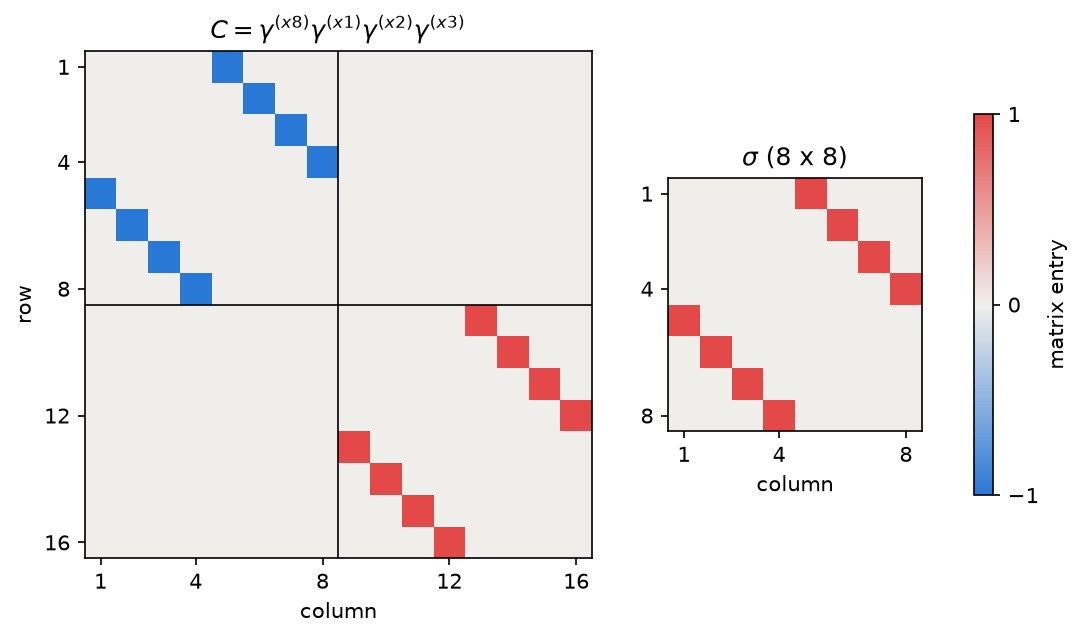

Figure 05a.1 saved as Revision/textbook/figures/05a_1_c_matrix.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.4), width_ratios=[2, 1])
heat_map(axes[0], C, r"$C = \gamma^{(x8)}\gamma^{(x1)}\gamma^{(x2)}\gamma^{(x3)}$")
image = heat_map(axes[1], sigma, r"$\sigma$ (8 x 8)", halves=False,
                 row_label=False)
fig.colorbar(image, ax=axes, ticks=[-1, 0, 1], shrink=0.75, label="matrix entry")
save_figure(fig, "c_matrix",
            "Heat maps of the charge matrix $C$ (left, 16 by 16) and of the "
            "author's 8 by 8 matrix $\\sigma$ (right); horizontal axis the column, "
            "vertical axis the row, numbered from 1; blue $-1$, grey $0$, red $+1$. "
            "The black lines cut $C$ into four 8 by 8 blocks: the top-left block "
            "is $-\\sigma$, the bottom-right block is $+\\sigma$ and the other two "
            "are zero, so $C = \\mathrm{diag}(-\\sigma, \\sigma)$. Every row and "
            "every column holds exactly one nonzero entry, and the picture is "
            "mirror-symmetric about the diagonal because $C^T = C$.")

The next cell checks the sign rule of section 4 for $C$: $C\gamma^a =
-\eta_{aa}\gamma^a C$, so $C$ anticommutes with the four space-like gammas and
commutes with the four time-like ones. It then checks two recorded consequences.
First, $C\gamma^a$ is antisymmetric: $(C\gamma^a)^T = (\gamma^a)^T C^T = \eta_{aa}
\gamma^a C = \eta_{aa}(-\eta_{aa}) C\gamma^a = -C\gamma^a$, because
$\eta_{aa}^2 = 1$. Second, $C\gamma^a C^{-1} = -(\gamma^a)^T$: multiply
$\gamma^a C = -\eta_{aa} C\gamma^a$ from the left by $C$ and use $CC = 1$ to get
$C\gamma^a C = -\eta_{aa}\gamma^a = -(\gamma^a)^T$.

In [9]:
signs_C = {x: commutation_sign(C, gamma[x]) for x in COORDS}  # +1 or -1 for each x
say("C gamma^(x) = s gamma^(x) C with s = "
    + ", ".join(f"{x}: {signs_C[x]:+d}" for x in COORDS))
check(all(signs_C[x] == -ETA[x] for x in COORDS),
      "C gamma^a = -eta_aa gamma^a C (anticommutes with space-like, commutes with "
      "time-like gammas)")
check_reproduces(all(np.array_equal((C @ gamma[x]).T, -(C @ gamma[x])) for x in COORDS)
                 and recorded("python", "C_gamma_antisymmetric"),
                 "C gamma^a is antisymmetric for every a",
                 record=record_of("python", "C_gamma_antisymmetric"))
check_reproduces(all(np.array_equal(C @ gamma[x] @ C, -gamma[x].T) for x in COORDS)
                 and recorded("python", "C_conjugation"),
                 "C gamma^a C^-1 = -(gamma^a)^T for every a",
                 record=record_of("python", "C_conjugation"))

C gamma^(x) = s gamma^(x) C with s = x1: -1, x2: -1, x3: -1, x4: +1, x5: +1, x6: +1, x7:
    +1, x8: -1
PASS C gamma^a = -eta_aa gamma^a C (anticommutes with space-like, commutes with time-like
    gammas)
PASS C gamma^a is antisymmetric for every a
     reproduces Revision/algebra/reports/python-algebra.json, check C_gamma_antisymmetric
PASS C gamma^a C^-1 = -(gamma^a)^T for every a
     reproduces Revision/algebra/reports/python-algebra.json, check C_conjugation


The next cell tests the squaring rule of section 4,
$PP = (-1)^{k(k-1)/2}\, \eta_{a_1 a_1} \cdots \eta_{a_k a_k} 1$, on **every** product
of different gammas taken in the order $x1, \dots, x8$: there are $2^8 - 1 = 255$ of
them (every non-empty subset of the eight directions). `itertools.combinations`
lists the subsets of each size $k$.

In [10]:
import itertools  # lists all subsets of a given size


def square_sign(directions):
    """The sign s of (gamma^(d1) ... gamma^(dk))^2 = s 1 predicted by the rule
    s = (-1)^(k (k - 1) / 2) times the product of the eta_dd."""
    k = len(directions)
    s = (-1) ** (k * (k - 1) // 2)  # // is division of whole numbers
    for d in directions:
        s *= ETA[d]
    return s


agree = 0  # how many subsets obey the rule
for k in range(1, 9):
    for subset in itertools.combinations(COORDS, k):
        p = product(subset)
        if np.array_equal(p @ p, square_sign(subset) * I16):
            agree += 1
say(f"subsets tested: 255; subsets that obey the squaring rule: {agree}")
for label, dirs in [("C", ["x8", "x1", "x2", "x3"]),
                    ("Gamma", ["x8", "x1", "x2", "x3", "x4", "x5", "x6", "x7"]),
                    ("C gamma^(x4)", ["x8", "x1", "x2", "x3", "x4"])]:
    say(f"({label})^2 = {square_sign(dirs):+d} times 1 (k = {len(dirs)})")
check(agree == 255, "the squaring rule holds for all 255 products of different gammas")

subsets tested: 255; subsets that obey the squaring rule: 255
(C)^2 = +1 times 1 (k = 4)
(Gamma)^2 = +1 times 1 (k = 8)
(C gamma^(x4))^2 = -1 times 1 (k = 5)
PASS the squaring rule holds for all 255 products of different gammas


## 7. C defines an indefinite quadratic form

For a real column $u$ of 16 numbers the number $u^T C u = \sum_{r,c} u_r C_{rc}
u_c$ is a *quadratic form*. Because $C$ has eigenvalues of both signs, this form
takes both signs. Take the path $u(t) = \cos t\, e_1 + \sin t\, e_5$, where $e_r$ is
the column with a 1 in row $r$ and zeros elsewhere. Only the entries $C_{1,5} =
C_{5,1}$ meet two nonzero components, so $u^T C u = 2 \cos t \sin t\, C_{1,5} =
C_{1,5} \sin 2t$ (double-angle formula $2\sin t\cos t = \sin 2t$). Along the path
$v(t) = \cos t\, e_9 + \sin t\, e_{13}$ the same steps give $C_{9,13} \sin 2t$. The
next cell reads $C_{1,5} = -1$ and $C_{9,13} = +1$ from the matrix (Python counts
rows from 0, so row 1 is index 0), evaluates both forms on 401 values of $t$ and
checks them against the formulas. It also computes the eigenvalues of $C$
(`np.linalg.eigvalsh` is made for symmetric matrices) and counts the positive and
negative ones.

In [11]:
t = np.linspace(0.0, np.pi, 401)  # 401 equally spaced values of t from 0 to pi
e = np.eye(16)  # e[r - 1] is the column e_r (a 1 in row r)
u = np.outer(np.cos(t), e[0]) + np.outer(np.sin(t), e[4])  # u(t), one per row
v = np.outer(np.cos(t), e[8]) + np.outer(np.sin(t), e[12])  # v(t), one per row
form_u = np.einsum("tr,rc,tc->t", u, C, u)  # u^T C u for every t at once
form_v = np.einsum("tr,rc,tc->t", v, C, v)  # v^T C v for every t at once
say(f"C_(1,5) = {C[0, 4]:+d} and C_(9,13) = {C[8, 12]:+d}")
check(C[0, 4] == -1 and C[8, 12] == 1
      and np.max(np.abs(form_u + np.sin(2 * t))) < 1e-14
      and np.max(np.abs(form_v - np.sin(2 * t))) < 1e-14,
      "u^T C u = -sin 2t and v^T C v = +sin 2t along the two paths")
eigenvalues_C = np.linalg.eigvalsh(C.astype(float))  # 16 real eigenvalues, sorted
n_plus = int(np.sum(np.abs(eigenvalues_C - 1.0) < 1e-9))  # how many are +1
n_minus = int(np.sum(np.abs(eigenvalues_C + 1.0) < 1e-9))  # how many are -1
say(f"trace of C = {int(np.trace(C))}; eigenvalues +1: {n_plus}, -1: {n_minus}")
check(np.trace(C) == 0 and n_plus == 8 and n_minus == 8,
      "C has eight eigenvalues +1 and eight -1: signature (8, 8)")

C_(1,5) = -1 and C_(9,13) = +1
PASS u^T C u = -sin 2t and v^T C v = +sin 2t along the two paths
trace of C = 0; eigenvalues +1: 8, -1: 8
PASS C has eight eigenvalues +1 and eight -1: signature (8, 8)


The next cell draws the two forms and, for comparison, the ordinary squared length
$u^T u = \cos^2 t + \sin^2 t = 1$, which never changes sign.

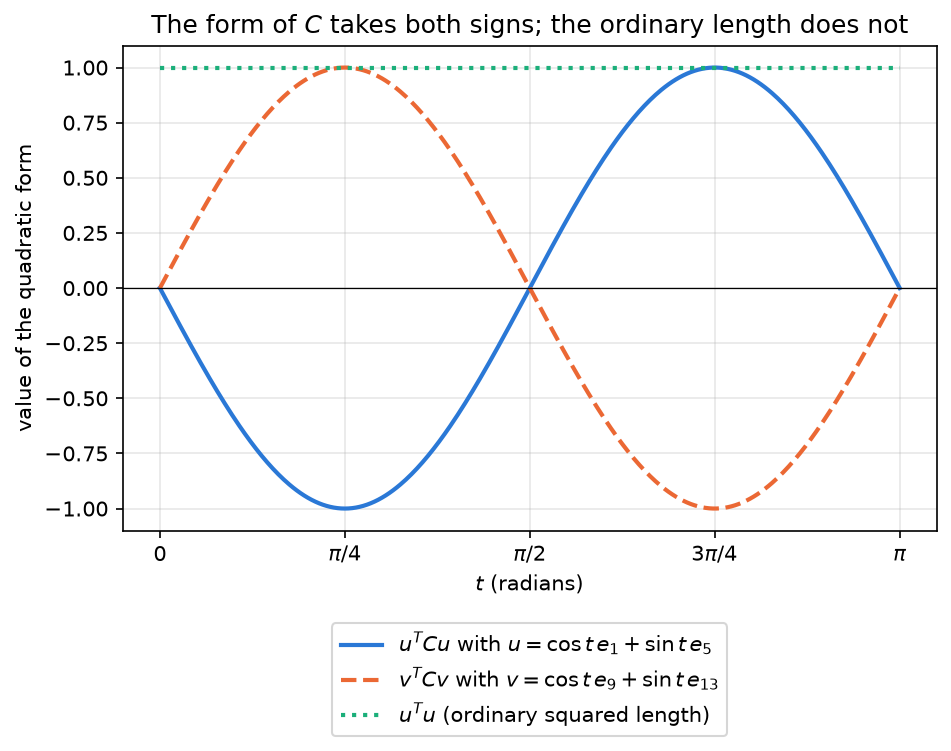

Figure 05a.2 saved as Revision/textbook/figures/05a_2_c_form_signs.png


In [12]:
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.plot(t, form_u, color="#2a78d6", linewidth=2,
        label=r"$u^T C u$ with $u = \cos t\, e_1 + \sin t\, e_5$")
ax.plot(t, form_v, color="#eb6834", linewidth=2, linestyle="--",
        label=r"$v^T C v$ with $v = \cos t\, e_9 + \sin t\, e_{13}$")
ax.plot(t, np.einsum("tr,tr->t", u, u), color="#1baf7a", linewidth=2,
        linestyle=":", label=r"$u^T u$ (ordinary squared length)")
ax.axhline(0.0, color="black", linewidth=0.6)
ax.set_xticks([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi],
              ["0", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
ax.set_xlabel("$t$ (radians)")
ax.set_ylabel("value of the quadratic form")
ax.set_title("The form of $C$ takes both signs; the ordinary length does not")
# the legend goes below the picture, where it hides no curve
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=1)
save_figure(fig, "c_form_signs",
            "The quadratic form of the charge matrix along two paths of unit "
            "columns, $u^T C u = -\\sin 2t$ (solid, components 1 and 5) and "
            "$v^T C v = +\\sin 2t$ (dashed, components 9 and 13), and the ordinary "
            "squared length $u^T u = 1$ (dotted), for $t$ from $0$ to $\\pi$; "
            "horizontal axis $t$ in radians, vertical axis the value (a pure "
            "number). The form of $C$ is negative for some unit columns and "
            "positive for others: $C$ has signature $(8, 8)$, an indefinite form.")

## 8. The chirality Gamma and the two halves

The next cell builds $\Gamma = \gamma^{(x8)} \gamma^{(x1)} \cdots \gamma^{(x7)}$ (the
author's product order) and checks four recorded facts:

1. $\Gamma$ equals the recorded matrix and is $\mathrm{diag}(-1_8, 1_8)$;
2. $\Gamma\Gamma = 1$ and $\Gamma$ anticommutes with every $\gamma^a$ (sign rule:
   every gamma is one of the 8 factors, $(-1)^{8-1} = -1$);
3. $\Gamma = C \gamma^{(x4)}\gamma^{(x5)}\gamma^{(x6)}\gamma^{(x7)}$ (the first four
   factors of $\Gamma$ are $C$);
4. $C\Gamma = \Gamma C$ (both are products of an even number of gammas),
   $\Gamma^T = \Gamma$, $\Gamma^T C \Gamma = C$ and
   $\Gamma^T C\gamma^a \Gamma = -C\gamma^a$ for every $a$.

Fact 4 is the matrix input of the pairing theorem T1 of the Revision record: the
map $\Psi \to \Gamma\Psi$ keeps the bilinear $\Psi^\dagger C \Psi$ (because
$(\Gamma\Psi)^\dagger C(\Gamma\Psi) = \Psi^\dagger\Gamma^T C\Gamma\Psi$, $\Gamma$
being real) and reverses the sign of every $\Psi^\dagger C\gamma^a E\Psi$ in which
$E$ is a product of an even number of gammas ($\Gamma$ commutes with such an $E$).

In [13]:
Gamma = product(["x8", "x1", "x2", "x3", "x4", "x5", "x6", "x7"])  # all eight
check_reproduces(np.array_equal(Gamma, np.array(fixture["Gamma"], dtype=np.int64))
                 and np.array_equal(Gamma, np.block([[-I8, Z8], [Z8, I8]]))
                 and recorded("python", "chirality_diag"),
                 "Gamma = gamma^(x8) gamma^(x1) ... gamma^(x7) = diag(-1_8, 1_8), as "
                 "recorded",
                 record=record_of("python", "chirality_diag"))
check_reproduces(np.array_equal(Gamma @ Gamma, I16)
                 and all(commutation_sign(Gamma, gamma[x]) == -1 for x in COORDS)
                 and recorded("python", "chirality_anticommutes"),
                 "Gamma Gamma = 1 and Gamma anticommutes with every gamma^a",
                 record=record_of("python", "chirality_anticommutes"))
check_reproduces(np.array_equal(Gamma, C @ product(["x4", "x5", "x6", "x7"]))
                 and recorded("python", "chirality_eq_C_times_time_gammas"),
                 "Gamma = C gamma^(x4) gamma^(x5) gamma^(x6) gamma^(x7)",
                 record=record_of("python", "chirality_eq_C_times_time_gammas"))
check_reproduces(commutation_sign(C, Gamma) == 1 and np.array_equal(Gamma.T, Gamma)
                 and np.array_equal(Gamma.T @ C @ Gamma, C)
                 and all(np.array_equal(Gamma.T @ C @ gamma[x] @ Gamma, -(C @ gamma[x]))
                         for x in COORDS)
                 and recorded("python", "chirality_C_relation"),
                 "C Gamma = Gamma C, Gamma^T C Gamma = C, Gamma^T C gamma^a Gamma = -C "
                 "gamma^a",
                 record=record_of("python", "chirality_C_relation"))

PASS Gamma = gamma^(x8) gamma^(x1) ... gamma^(x7) = diag(-1_8, 1_8), as recorded
     reproduces Revision/algebra/reports/python-algebra.json, check chirality_diag
PASS Gamma Gamma = 1 and Gamma anticommutes with every gamma^a
     reproduces Revision/algebra/reports/python-algebra.json, check
    chirality_anticommutes
PASS Gamma = C gamma^(x4) gamma^(x5) gamma^(x6) gamma^(x7)
     reproduces Revision/algebra/reports/python-algebra.json, check
    chirality_eq_C_times_time_gammas
PASS C Gamma = Gamma C, Gamma^T C Gamma = C, Gamma^T C gamma^a Gamma = -C gamma^a
     reproduces Revision/algebra/reports/python-algebra.json, check chirality_C_relation


Because $\Gamma\Gamma = 1$, the matrices $P_- = \tfrac12(1 - \Gamma)$ and
$P_+ = \tfrac12(1 + \Gamma)$ are projectors: $P_-P_- = \tfrac14(1 - 2\Gamma +
\Gamma\Gamma) = \tfrac14(2 - 2\Gamma) = P_-$, and in the same way $P_+P_+ = P_+$ and
$P_-P_+ = \tfrac14(1 - \Gamma\Gamma) = 0$. With $\Gamma = \mathrm{diag}(-1_8, 1_8)$,
$P_- = \mathrm{diag}(1_8, 0)$ keeps the first half of a column (components 1 to 8,
chirality $-1$) and $P_+ = \mathrm{diag}(0, 1_8)$ the second half (9 to 16,
chirality $+1$). Since $\gamma^a\Gamma = -\Gamma\gamma^a$, we get $\gamma^a P_- =
\tfrac12(\gamma^a + \Gamma\gamma^a) = P_+\gamma^a$: every gamma carries the first
half into the second and back, so every gamma has zero diagonal blocks. The next
cell checks all of this (`//` divides whole numbers exactly; the entries of
$1 \pm \Gamma$ are 0 or 2).

In [14]:
P_minus = (I16 - Gamma) // 2  # the projector onto components 1 to 8
P_plus = (I16 + Gamma) // 2  # the projector onto components 9 to 16
check(np.array_equal(P_minus, np.block([[I8, Z8], [Z8, Z8]]))
      and np.array_equal(P_plus, np.block([[Z8, Z8], [Z8, I8]]))
      and np.array_equal(P_minus @ P_minus, P_minus)
      and np.array_equal(P_plus @ P_plus, P_plus)
      and not np.any(P_minus @ P_plus) and np.array_equal(P_minus + P_plus, I16)
      and np.trace(P_minus) == 8 and np.trace(P_plus) == 8,
      "P_- = diag(1_8, 0) and P_+ = diag(0, 1_8) are complementary projectors of rank 8")
check_reproduces(all(np.array_equal(gamma[x] @ P_minus, P_plus @ gamma[x])
                     for x in COORDS)
                 and all(not np.any(gamma[x][:8, :8]) and not np.any(gamma[x][8:, 8:])
                         for x in COORDS)
                 and recorded("python", "reflections_exchange_halves")
                 and recorded("wolfram", "Spin_Pin_reflection_swaps_halves"),
                 "gamma^a P_- = P_+ gamma^a: every gamma exchanges the two halves",
                 record=record_of("python", "reflections_exchange_halves"))

PASS P_- = diag(1_8, 0) and P_+ = diag(0, 1_8) are complementary projectors of rank 8
PASS gamma^a P_- = P_+ gamma^a: every gamma exchanges the two halves
     reproduces Revision/algebra/reports/python-algebra.json, check
    reflections_exchange_halves


The next cell draws $\Gamma$, the two projectors and, for comparison,
$\gamma^{(x1)}$: the chirality and the projectors live in the diagonal blocks, a
gamma lives in the off-diagonal blocks.

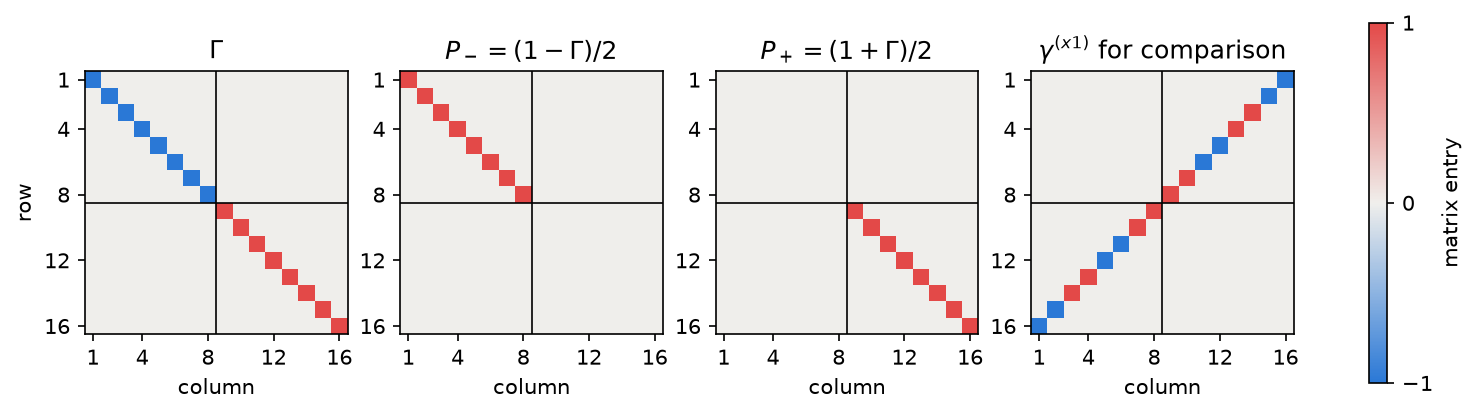

Figure 05a.3 saved as Revision/textbook/figures/05a_3_chirality.png


In [15]:
fig, axes = plt.subplots(1, 4, figsize=(13.0, 3.9))
heat_map(axes[0], Gamma, r"$\Gamma$")
heat_map(axes[1], P_minus, r"$P_- = (1 - \Gamma)/2$", row_label=False)
heat_map(axes[2], P_plus, r"$P_+ = (1 + \Gamma)/2$", row_label=False)
image = heat_map(axes[3], gamma["x1"], r"$\gamma^{(x1)}$ for comparison",
                 row_label=False)
fig.colorbar(image, ax=axes, ticks=[-1, 0, 1], shrink=0.8, label="matrix entry")
save_figure(fig, "chirality",
            "Heat maps of the chirality $\\Gamma$, of the projectors $P_-$ and "
            "$P_+$ onto the two halves, and of the gamma matrix of the direction "
            "$x1$; horizontal axis the column, vertical axis the row (1 to 16); "
            "blue $-1$, grey $0$, red $+1$. $\\Gamma = \\mathrm{diag}(-1, 1)$ is "
            "blue on the first eight diagonal places and red on the last eight; "
            "$P_-$ keeps components 1 to 8 and $P_+$ components 9 to 16. The gamma "
            "has nonzero entries only in the two off-diagonal blocks: it carries "
            "one half into the other.")

## 9. The matrix B

The next cell builds $B = -i\, C\gamma^{(x4)}$ (in Python the imaginary unit is
written `1j`) and checks it against the record, which stores the real and the
imaginary part separately. Then it checks the recorded properties: $B$ is purely
imaginary, Hermitian ($B^\dagger = B$), $BB = 1$ and $\mathrm{tr}\, B = 0$. Why
Hermitian: $C\gamma^{(x4)}$ is real and antisymmetric (section 6), so
$B^\dagger = (+i)(C\gamma^{(x4)})^T = (+i)(-C\gamma^{(x4)}) = B$. The entries of $B$
are $0$, $i$ or $-i$, so every product is again exact.

In [16]:
B = -1j * (C @ gamma["x4"])  # B = -i C gamma^(x4); 1j is the imaginary unit
B_record = (np.array(fixture["B"]["re"], dtype=np.int64)
            + 1j * np.array(fixture["B"]["im"], dtype=np.int64))
check_reproduces(np.array_equal(B, B_record) and recorded("wolfram", "B_definition"),
                 "B = -i C gamma^(x4) equals the recorded B",
                 record=record_of("wolfram", "B_definition"))
check_reproduces(not np.any(B.real) and np.array_equal(B.conj().T, B)
                 and np.array_equal(B @ B, I16) and np.trace(B) == 0
                 and recorded("python", "B_hermitian_involution_signature")
                 and recorded("wolfram", "B_Hermitian")
                 and recorded("wolfram", "B_squared_identity"),
                 "B is purely imaginary and Hermitian, B B = 1 and tr B = 0",
                 record=record_of("python", "B_hermitian_involution_signature"))

PASS B = -i C gamma^(x4) equals the recorded B
     reproduces Revision/algebra/reports/wolfram-algebra.json, check B_definition
PASS B is purely imaginary and Hermitian, B B = 1 and tr B = 0
     reproduces Revision/algebra/reports/python-algebra.json, check
    B_hermitian_involution_signature


The next cell computes the *characteristic polynomial*
$\det(\lambda 1 - B)$ of $B$ exactly with sympy (whose roots are the eigenvalues)
and factors it. The result must be $(\lambda - 1)^8 (\lambda + 1)^8$: eight
eigenvalues $+1$ and eight $-1$, the signature $(8, 8)$ of the Hermitian form
$\Psi^\dagger B \Psi$. The recorded check states the same polynomial in its detail
text, which the cell compares character by character (sympy writes `**` for a
power and `*` for a product).

In [17]:
import sympy as sp  # exact algebra with symbols

lam = sp.Symbol("lam")  # the variable lambda of the polynomial
B_exact = sp.I * sp.Matrix((-(C @ gamma["x4"])).tolist())  # B with exact sympy numbers
polynomial = sp.factor(B_exact.charpoly(lam).as_expr())  # det(lam 1 - B), factored
say(f"characteristic polynomial of B: {polynomial}")
detail = VERDICTS[("python", "B_hermitian_involution_signature")][1]
check_reproduces(sp.expand(polynomial - (lam - 1) ** 8 * (lam + 1) ** 8) == 0
                 and f"= {polynomial}" in detail
                 and recorded("wolfram", "B_signature_8_8"),
                 "det(lam 1 - B) = (lam - 1)^8 (lam + 1)^8: signature (8, 8)",
                 record=record_of("python", "B_hermitian_involution_signature"))

characteristic polynomial of B: (lam - 1)**8*(lam + 1)**8
PASS det(lam 1 - B) = (lam - 1)^8 (lam + 1)^8: signature (8, 8)
     reproduces Revision/algebra/reports/python-algebra.json, check
    B_hermitian_involution_signature


The next cell finds with which gammas $B$ commutes. By the sign rule of section 4,
$C\gamma^{(x4)}$ is a product of the five different gammas $x8, x1, x2, x3, x4$: a
gamma among them passes four others and commutes, $(-1)^4 = +1$; a gamma not among
them ($x5, x6, x7$) passes five and anticommutes. The factor $-i$ does not change
this. The recorded check states exactly this pattern.

In [18]:
signs_B = {x: commutation_sign(B, gamma[x]) for x in COORDS}
commute = [x for x in COORDS if signs_B[x] == 1]
anticommute = [x for x in COORDS if signs_B[x] == -1]
say("B commutes with gamma^(x) for x = " + ", ".join(commute))
say("B anticommutes with gamma^(x) for x = " + ", ".join(anticommute))
check_reproduces(commute == ["x1", "x2", "x3", "x4", "x8"]
                 and anticommute == ["x5", "x6", "x7"]
                 and recorded("python", "B_gamma_relations"),
                 "B commutes with gamma^a for a = x1, x2, x3, x4, x8 and anticommutes "
                 "for x5, x6, x7",
                 record=record_of("python", "B_gamma_relations"))

B commutes with gamma^(x) for x = x1, x2, x3, x4, x8
B anticommutes with gamma^(x) for x = x5, x6, x7
PASS B commutes with gamma^a for a = x1, x2, x3, x4, x8 and anticommutes for x5, x6, x7
     reproduces Revision/algebra/reports/python-algebra.json, check B_gamma_relations


The next cell draws the three matrices from which $B$ is made: $\gamma^{(x4)}$,
the real antisymmetric matrix $C\gamma^{(x4)}$, and the imaginary part of $B$,
which is $-C\gamma^{(x4)}$ (the real part of $B$ is zero).

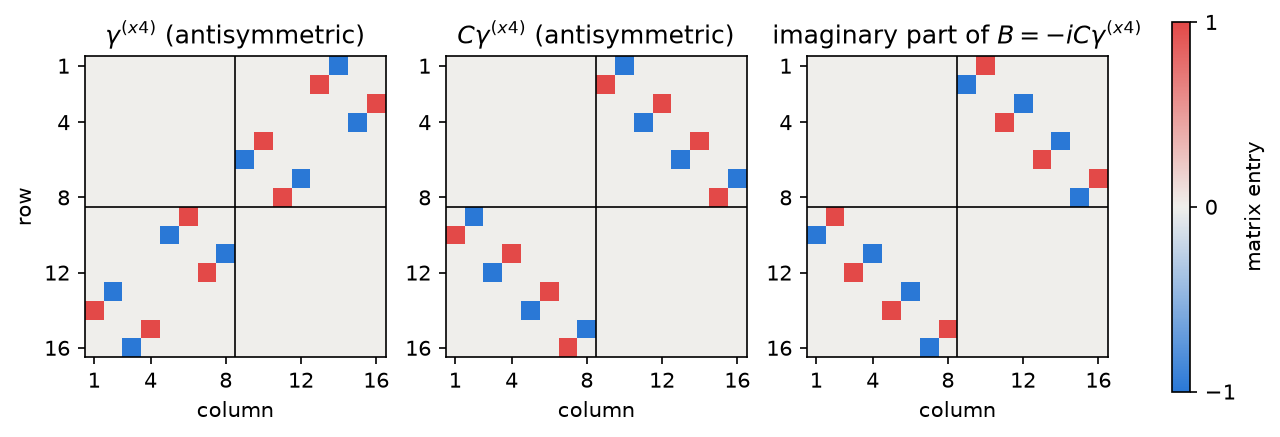

Figure 05a.4 saved as Revision/textbook/figures/05a_4_b_matrix.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(11.0, 4.0))
heat_map(axes[0], gamma["x4"], r"$\gamma^{(x4)}$ (antisymmetric)")
heat_map(axes[1], C @ gamma["x4"], r"$C\gamma^{(x4)}$ (antisymmetric)",
         row_label=False)
image = heat_map(axes[2], B.imag, r"imaginary part of $B = -iC\gamma^{(x4)}$",
                 row_label=False)
fig.colorbar(image, ax=axes, ticks=[-1, 0, 1], shrink=0.8, label="matrix entry")
save_figure(fig, "b_matrix",
            "Heat maps of the gamma matrix of the time $x4$ (left), of the product "
            "$C\\gamma^{(x4)}$ (middle) and of the imaginary part of "
            "$B = -iC\\gamma^{(x4)}$ (right); horizontal axis the column, vertical "
            "axis the row (1 to 16); blue $-1$, grey $0$, red $+1$. Each picture "
            "changes colour when it is mirrored about the diagonal: the three "
            "real matrices are antisymmetric. $B$ is $i$ times an antisymmetric "
            "real matrix, which makes it Hermitian.")

## 10. The spectra

The next cell computes the eigenvalues of the eight gammas, of $C$, $\Gamma$ and
$B$ with `np.linalg.eigvals` (floating-point numbers, correct to about 15 digits)
and counts how many lie within $10^{-9}$ of each of $+1$, $-1$, $+i$ and $-i$.
Section 4 predicts: a matrix with $MM = 1$ and trace 0 has eight eigenvalues $+1$
and eight $-1$; one with $MM = -1$ and trace 0 has eight $+i$ and eight $-i$. The
exact facts behind the prediction ($MM = \pm 1$, trace 0) were checked above for
$C$, $\Gamma$ and $B$; for the gammas the cell checks the traces.

In [20]:
TARGETS = [1, -1, 1j, -1j]  # the four possible eigenvalues
TARGET_NAMES = ["+1", "-1", "+i", "-i"]
matrices = {f"gamma^({x})": gamma[x] for x in COORDS}
matrices.update({"C": C, "Gamma": Gamma, "B": B})
counts = {}  # name -> [how many eigenvalues near +1, -1, +i, -i]
for name, m in matrices.items():
    eigenvalues = np.linalg.eigvals(m.astype(complex))
    counts[name] = [int(np.sum(np.abs(eigenvalues - z) < 1e-9)) for z in TARGETS]
    say(f"{name:12} " + "  ".join(f"{n}: {c}" for n, c in
                                  zip(TARGET_NAMES, counts[name])))
predicted = {name: ([8, 8, 0, 0] if name in ("C", "Gamma", "B")
                    or ETA[name[7:9]] == 1 else [0, 0, 8, 8]) for name in matrices}
check(counts == predicted and all(np.trace(gamma[x]) == 0 for x in COORDS),
      "eigenvalues: +1 and -1 eight times each for the space-like gammas, C, Gamma "
      "and B; +i and -i eight times each for the time-like gammas")

gamma^(x1)   +1: 8  -1: 8  +i: 0  -i: 0
gamma^(x2)   +1: 8  -1: 8  +i: 0  -i: 0
gamma^(x3)   +1: 8  -1: 8  +i: 0  -i: 0
gamma^(x4)   +1: 0  -1: 0  +i: 8  -i: 8
gamma^(x5)   +1: 0  -1: 0  +i: 8  -i: 8
gamma^(x6)   +1: 0  -1: 0  +i: 8  -i: 8
gamma^(x7)   +1: 0  -1: 0  +i: 8  -i: 8
gamma^(x8)   +1: 8  -1: 8  +i: 0  -i: 0
C            +1: 8  -1: 8  +i: 0  -i: 0
Gamma        +1: 8  -1: 8  +i: 0  -i: 0
B            +1: 8  -1: 8  +i: 0  -i: 0
PASS eigenvalues: +1 and -1 eight times each for the space-like gammas, C, Gamma and B;
    +i and -i eight times each for the time-like gammas


The next cell draws the table of these counts as a picture: one row per matrix,
one column per possible eigenvalue, the count written in each square.

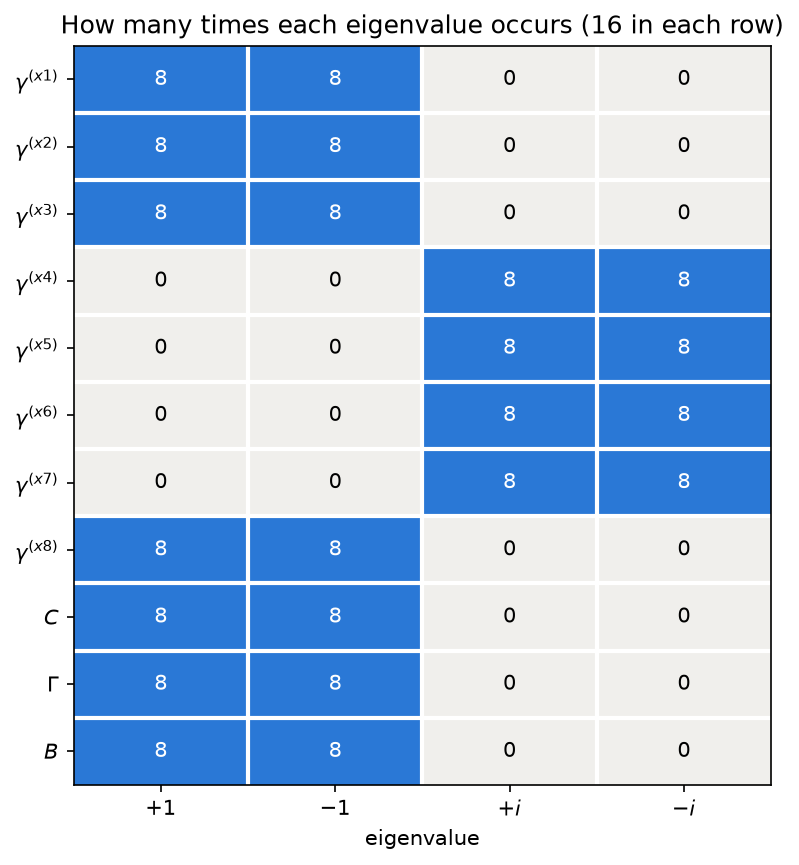

Figure 05a.5 saved as Revision/textbook/figures/05a_5_spectra.png


In [21]:
from matplotlib.colors import LinearSegmentedColormap as Ramp

names = list(matrices)  # the 11 matrices in the order of the table
table = np.array([counts[name] for name in names])  # 11 rows, 4 columns
COUNT_COLORS = Ramp.from_list("counts", ["#f0efec", "#2a78d6"])  # 0 grey, 8 blue
fig, ax = plt.subplots(figsize=(6.0, 6.4))
ax.imshow(table, cmap=COUNT_COLORS, vmin=0, vmax=8, aspect="auto")
for k in range(1, table.shape[0]):  # white gaps between the rows
    ax.axhline(k - 0.5, color="white", linewidth=2)
for k in range(1, table.shape[1]):  # and between the columns
    ax.axvline(k - 0.5, color="white", linewidth=2)
for r in range(table.shape[0]):
    for c in range(table.shape[1]):
        ax.text(c, r, str(table[r, c]), ha="center", va="center",
                color="white" if table[r, c] == 8 else "black")
ax.set_xticks(range(4), ["$+1$", "$-1$", "$+i$", "$-i$"])
labels = [rf"$\gamma^{{({x})}}$" for x in COORDS] + ["$C$", r"$\Gamma$", "$B$"]
ax.set_yticks(range(len(names)), labels)
ax.set_xlabel("eigenvalue")
ax.set_title("How many times each eigenvalue occurs (16 in each row)")
ax.grid(False)
save_figure(fig, "spectra",
            "The spectra of the eight gamma matrices and of $C$, $\\Gamma$ and $B$: "
            "each row is one 16 by 16 matrix, each column one possible eigenvalue "
            "($+1$, $-1$, $+i$, $-i$), and each square holds how many of its 16 "
            "eigenvalues equal that number. The space-like gammas ($x1, x2, x3, "
            "x8$), $C$, $\\Gamma$ and $B$ square to $1$ and have eigenvalues "
            "$+1$ and $-1$ eight times each; the time-like gammas ($x4$ to $x7$) "
            "square to $-1$ and have $+i$ and $-i$ eight times each.")

## 11. A table of commutation signs

The next cell collects, for each of $C$, $\Gamma$ and $B$ and each gamma, the sign
$s$ in $M\gamma^a = s\,\gamma^a M$ and draws the table. Section 4 predicts every
entry: $C$ has $s = -\eta_{aa}$; $\Gamma$ has $s = -1$ for all $a$; $B$ has $s = +1$
for $x1, x2, x3, x4, x8$ and $s = -1$ for $x5, x6, x7$.

PASS the commutation signs of C, Gamma and B with the eight gammas are as predicted


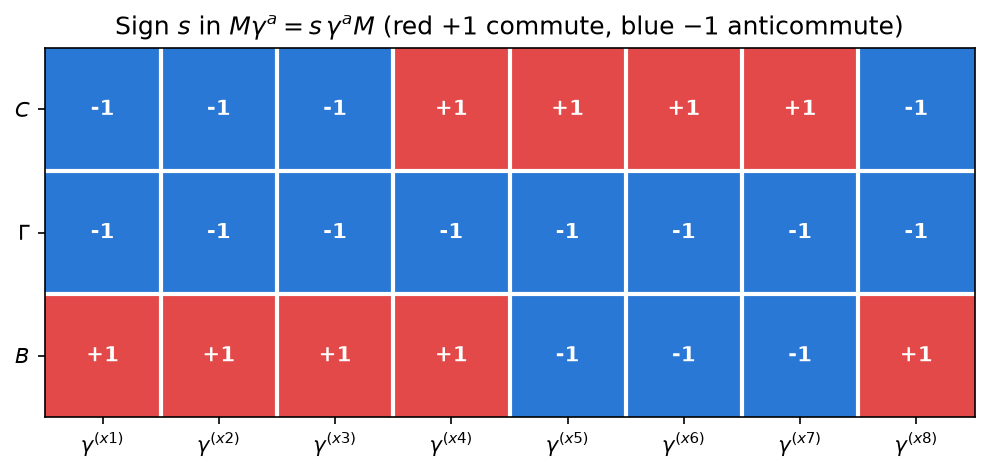

Figure 05a.6 saved as Revision/textbook/figures/05a_6_commutation_signs.png


In [22]:
rows = {"C": signs_C, "Gamma": {x: commutation_sign(Gamma, gamma[x]) for x in COORDS},
        "B": signs_B}
sign_table = np.array([[rows[name][x] for x in COORDS] for name in rows])
expected_table = np.array([[-ETA[x] for x in COORDS], [-1] * 8,
                           [1, 1, 1, 1, -1, -1, -1, 1]])
check(np.array_equal(sign_table, expected_table),
      "the commutation signs of C, Gamma and B with the eight gammas are as predicted")
fig, ax = plt.subplots(figsize=(8.0, 3.2))
ax.imshow(sign_table, cmap=SIGNS, vmin=-1, vmax=1, aspect="auto")
for k in range(1, 3):  # white gaps between the rows
    ax.axhline(k - 0.5, color="white", linewidth=2)
for k in range(1, 8):  # and between the columns
    ax.axvline(k - 0.5, color="white", linewidth=2)
for r in range(3):
    for c in range(8):
        ax.text(c, r, f"{sign_table[r, c]:+d}", ha="center", va="center",
                color="white", fontweight="bold")
ax.set_xticks(range(8), [rf"$\gamma^{{({x})}}$" for x in COORDS])
ax.set_yticks(range(3), ["$C$", r"$\Gamma$", "$B$"])
ax.set_title(r"Sign $s$ in $M\gamma^a = s\,\gamma^a M$ (red $+1$ commute, "
             r"blue $-1$ anticommute)")
ax.grid(False)
save_figure(fig, "commutation_signs",
            "The commutation signs: row $M$ ($C$, $\\Gamma$ or $B$) and column "
            "$\\gamma^a$ show the sign $s$ in $M\\gamma^a = s\\,\\gamma^a M$; red "
            "$+1$ means the two commute, blue $-1$ that they anticommute. $C$ "
            "anticommutes with the space-like gammas $x1, x2, x3, x8$ and "
            "commutes with the time-like ones; $\\Gamma$ anticommutes with every "
            "gamma; $B$ anticommutes only with the extra times $x5, x6, x7$.")

## 12. The last check

The last cell checks that the six figure files exist and prints the number of
checks that passed.

In [23]:
FIGURES = ["05a_1_c_matrix.png", "05a_2_c_form_signs.png", "05a_3_chirality.png",
           "05a_4_b_matrix.png", "05a_5_spectra.png", "05a_6_commutation_signs.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in FIGURES),
      "the six figure files of notebook 05a exist")
all_checks_passed()

PASS the six figure files of notebook 05a exist
ALL 26 CHECKS PASSED (notebook 05a)


## 13. What this notebook showed

- The eight gammas of the Revision record are real signed permutation matrices
  that obey the Clifford relation $\{\gamma^a, \gamma^b\} = 2\eta^{ab}1$; the
  space-like ones ($x1, x2, x3, x8$) are symmetric, the time-like ones ($x4, x5,
  x6, x7$) antisymmetric.
- $C = \gamma^{(x8)}\gamma^{(x1)}\gamma^{(x2)}\gamma^{(x3)} =
  \mathrm{diag}(-\sigma, \sigma)$ is real and symmetric, $CC = 1$, it anticommutes
  with the space-like and commutes with the time-like gammas, every $C\gamma^a$ is
  antisymmetric and $C\gamma^a C^{-1} = -(\gamma^a)^T$. Its quadratic form has
  signature $(8, 8)$: it takes both signs.
- $\Gamma = \gamma^{(x8)}\gamma^{(x1)}\cdots\gamma^{(x7)} = \mathrm{diag}(-1_8,
  1_8)$ squares to 1, anticommutes with every gamma, commutes with $C$ and
  satisfies $\Gamma^T C\Gamma = C$ and $\Gamma^T C\gamma^a\Gamma = -C\gamma^a$. Its
  projectors split the 16 components into two halves of 8, and every gamma
  exchanges the halves.
- $B = -iC\gamma^{(x4)}$ is purely imaginary and Hermitian with $BB = 1$, its
  characteristic polynomial is $(\lambda - 1)^8(\lambda + 1)^8$ (signature
  $(8, 8)$), and it anticommutes exactly with the gammas of the three extra times.
- The squaring rule $(-1)^{k(k-1)/2}\prod\eta$ holds for all 255 products of
  different gammas.
- Every one of these facts reproduces a check of the Revision reports
  `Revision/algebra/reports/python-algebra.json` and `wolfram-algebra.json`, whose
  verdicts the notebook read and confirmed.